# Post 03: How Do Timestep, Precision, and Force Error Become Simulation Error?

This notebook is the presentation layer for the third tutorial. The reusable timestep, precision, force-error, and plotting logic lives in `src/kups_md_tutorials/`.

The goal is to keep three failure modes separate: bounded timestep error, precision or rounding floors, and systematic force errors that look like drift.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.config import load_error_spec
from kups_md_tutorials.error_diagnostics import (
    integrate_with_error,
    load_error_summary,
)
from kups_md_tutorials.figures import generate_post03_figures
from kups_md_tutorials.integrators import exact_harmonic

## Configuration

The smoke and full profiles use a controlled oscillator so the exact trajectory is known. The full profile sweeps timesteps, precision models, and deterministic force-scale errors.

In [3]:
smoke_spec = load_error_spec("03", "smoke")
full_spec = load_error_spec("03", "full")

for label in ["smoke", "full"]:
    config_path = Path(f"configs/post-03/{label}.json")
    print(f"--- {label} ---")
    print(json.dumps(json.loads(config_path.read_text()), indent=2))

--- smoke ---
{
  "post": "03",
  "profile": "smoke",
  "title": "How Do Timestep, Precision, and Force Error Become Simulation Error?",
  "system": {
    "kind": "harmonic_oscillator",
    "mass": 1.0,
    "omega": 1.0,
    "position": 1.0,
    "velocity": 0.0
  },
  "error_experiment": {
    "num_steps": 500,
    "time_steps": [
      0.04,
      0.12
    ],
    "precisions": [
      "float64",
      "float32",
      "rounded_1e-4"
    ],
    "force_cases": [
      {
        "name": "exact_force",
        "force_scale": 1.0
      },
      {
        "name": "biased_low_force",
        "force_scale": 0.98
      }
    ]
  },
  "argon_nve": {
    "protocol_label": "smoke_lj_nve_replicas",
    "repetitions": 2,
    "number_density": 0.65,
    "temperature": 0.7,
    "seed": 3031,
    "replica_count": 2,
    "num_steps": 400,
    "sample_every": 5,
    "time_steps": [
      0.002,
      0.005
    ],
    "epsilon": 1.0,
    "sigma": 1.0,
    "cutoff": 2.5,
    "target_device": "cpu"
  }
}
-

## One Trajectory, Three Error Sources

For the exact-force float64 case, velocity Verlet has bounded discretization error. Coarser precision changes the map even with the same force, and force scaling changes the Hamiltonian being integrated.

In [4]:
times, q64, v64 = integrate_with_error(
    time_step=0.18,
    num_steps=16,
    mass=full_spec.system.mass,
    omega=full_spec.system.omega,
    position0=full_spec.system.position,
    velocity0=full_spec.system.velocity,
    precision="float64",
    force_scale=1.0,
)
exact_q, _ = exact_harmonic(
    times,
    full_spec.system.position,
    full_spec.system.velocity,
    full_spec.system.omega,
)
list(zip(times[:6], q64[:6], exact_q[:6], q64[:6] - exact_q[:6]))

[(np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(0.0)),
 (np.float64(0.18),
  np.float64(0.9838),
  np.float64(0.9838436927881214),
  np.float64(-4.369278812144106e-05)),
 (np.float64(0.36),
  np.float64(0.93572488),
  np.float64(0.9358968236779348),
  np.float64(-0.00017194367793482712)),
 (np.float64(0.54),
  np.float64(0.857332273888),
  np.float64(0.8577086813638242),
  np.float64(-0.00037640747582412537)),
 (np.float64(0.72),
  np.float64(0.7511621021020288),
  np.float64(0.751805729140895),
  np.float64(-0.0006436270388662235)),
 (np.float64(0.8999999999999999),
  np.float64(0.6206542782079518),
  np.float64(0.6216099682706645),
  np.float64(-0.0009556900627126774))]

## Committed Outputs

The repository commits smoke and full summaries plus downsampled comparison samples. The full summary is the source for the diagnostic figure.

In [5]:
result_dirs = {
    "smoke": Path("results/post-03/smoke"),
    "full": Path("results/post-03/full"),
}

for label, result_dir in result_dirs.items():
    print(f"--- {label} ---")
    for path in sorted(result_dir.iterdir()):
        print(f"{path}: {path.stat().st_size} bytes")

full_summary = load_error_summary(result_dirs["full"] / "error_summary.json")
full_summary

--- smoke ---
results/post-03/smoke/argon_nve_samples.csv: 10332 bytes
results/post-03/smoke/error_samples.csv: 29733 bytes
results/post-03/smoke/error_summary.json: 8690 bytes
results/post-03/smoke/manifest.json: 1869 bytes
--- full ---
results/post-03/full/argon_nve_samples.csv: 34983 bytes
results/post-03/full/error_samples.csv: 35131 bytes
results/post-03/full/error_summary.json: 28639 bytes
results/post-03/full/manifest.json: 2048 bytes


ErrorExperimentSummary(post='03', profile='full', mass=1.0, omega=1.0, initial_position=1.0, initial_velocity=0.0, config_sha256='a6818fb26ac22f32448b51b1496288ae552c468e4db69d2f8e04e338cb0d8d12', runs=[ErrorRunSummary(time_step=0.02, precision='float64', force_case='exact_force', force_scale=1.0, final_time=60.0, initial_energy=0.5, final_energy=0.4999953254517056, normalized_energy_drift=-1.5581827647973926e-07, max_abs_relative_energy_error=9.999999998844267e-05, rms_position_error=0.00040517135619044136, final_position_error=0.0003053005368991446, unstable=False), ErrorRunSummary(time_step=0.02, precision='float64', force_case='biased_low_force', force_scale=0.98, final_time=60.0, initial_energy=0.5, final_energy=0.4991655629606599, normalized_energy_drift=-2.7814567978003597e-05, max_abs_relative_energy_error=0.02009603953311756, rms_position_error=0.24342951705054702, final_position_error=-0.005164733288924084, unstable=False), ErrorRunSummary(time_step=0.02, precision='float64',

## Diagnostic Figure

The figure uses the full profile. It separates timestep sensitivity, precision floors, and force bias so later kUPS NVE diagnostics can report them separately rather than collapsing everything into one drift number.

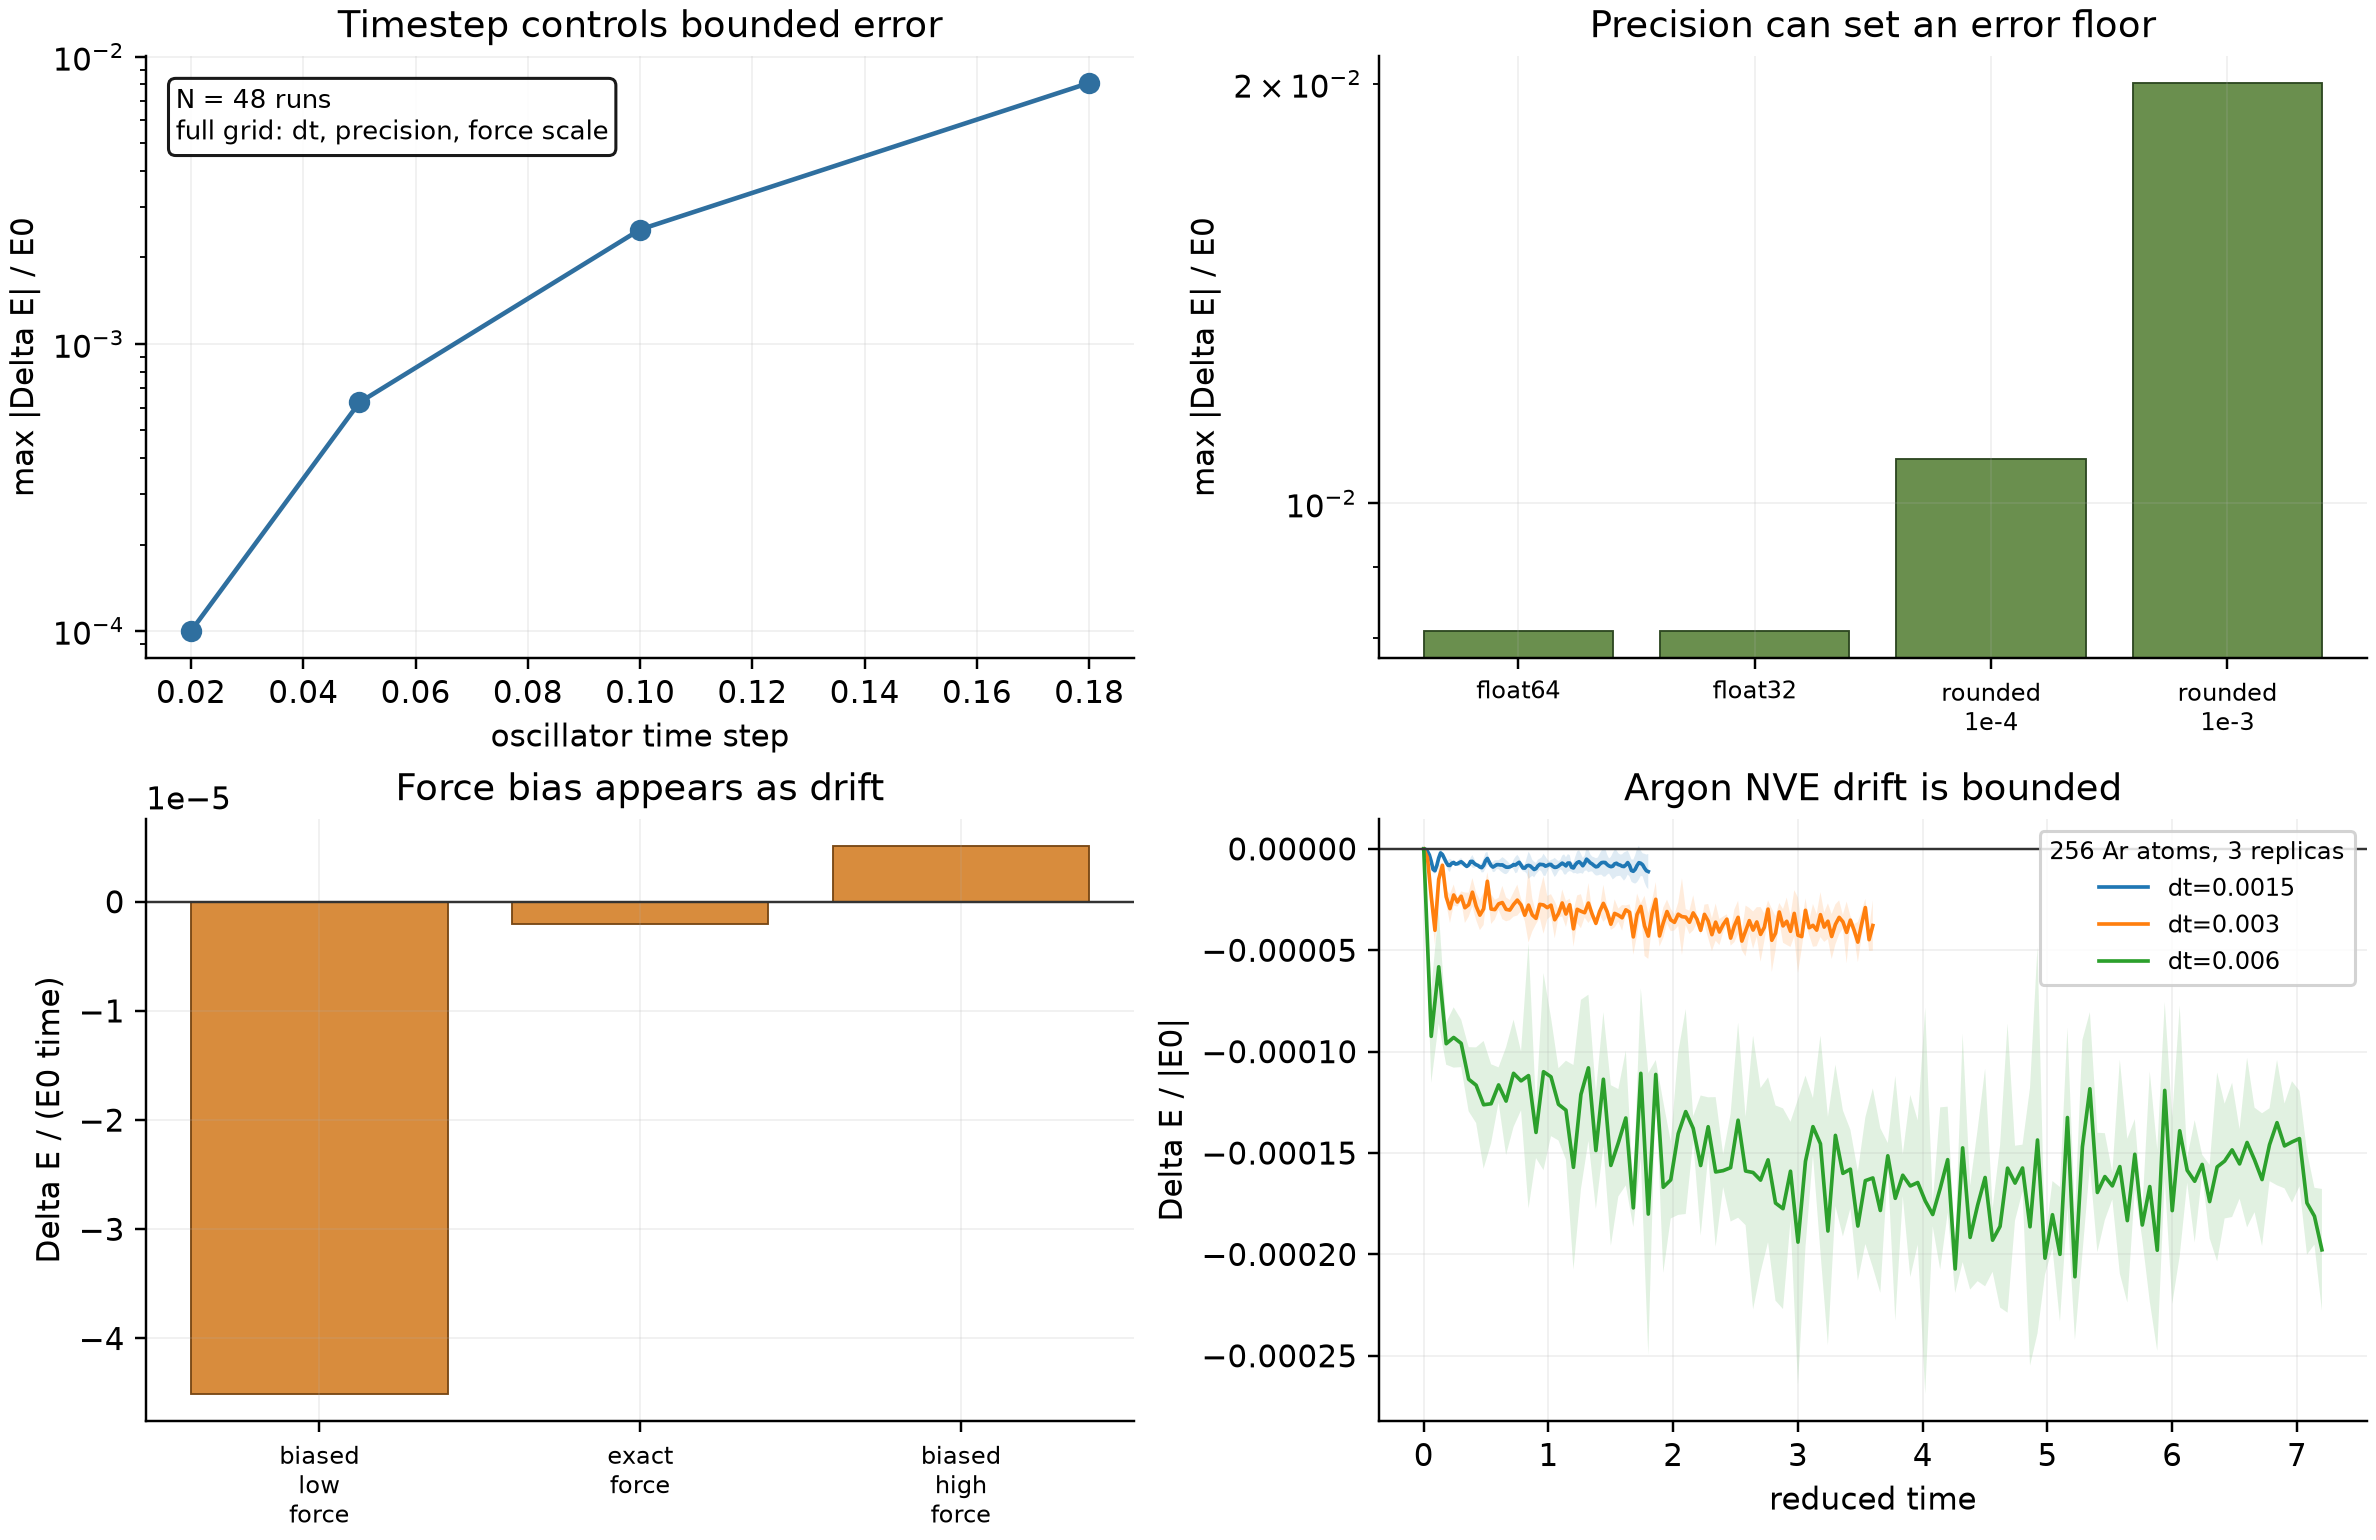

In [6]:
generate_post03_figures(
    result_dir=result_dirs["full"],
    figure_dir=Path("figures/post-03"),
    snapshot_dir=Path("snapshots/post-03"),
    name="error_diagnostics_full",
)
display(Image(filename="figures/post-03/error_diagnostics_full.png"))

## Argon NVE Protocol Check

The full profile aggregates a larger reduced-unit argon NVE check across timesteps and independent velocity seeds. This is a GPU-ready reproducibility protocol, but the committed run records CPU fallback unless a CUDA-enabled stack is available.


In [7]:
protocol = full_summary.argon_nve_protocol
if protocol is not None:
    print("protocol=", protocol.protocol_label)
    print("target_device=", protocol.target_device)
    print("atoms=", protocol.atom_count)
    print("replicas=", protocol.replica_count)
    print("timesteps=", protocol.time_step_count)
    print("max |dE|/|E0|=", f"{protocol.max_abs_relative_energy_error:.3e}")
    print("max |drift|=", f"{protocol.max_abs_normalized_energy_drift:.3e}")
    print("max drift SE=", f"{protocol.replica_drift_standard_error_max:.3e}")


protocol= gpu_ready_lj_nve_replicas
target_device= cuda_or_cpu_fallback
atoms= 256
replicas= 3
timesteps= 3
max |dE|/|E0|= 2.647e-04
max |drift|= 3.118e-05
max drift SE= 2.794e-06


## Takeaways

- Timestep error can appear as bounded energy oscillation rather than monotonic drift.
- Precision and rounding can set an error floor even when the mathematical force is exact.
- Systematic force bias changes the energy behavior and should be reported separately from timestep error.
- The controlled oscillator is a microscope; the compact argon NVE check adds a physical many-body sanity check, while final GPU kUPS and MLIP production diagnostics still need larger post-series review.